# Exploring, Visualizing and Training ML model iris Dataset

## INTRODUCTION
- The Iris dataset is a famous benchmark dataset in machine learning, collected by Ronald Fisher in 1936. It contains measurements of 150 iris flowers across 3 species.

## PROBLEM STATEMENT
### Core Problem
- Given:    Measurements of sepal/petal length and width of a flower
- Find:     Which of the 3 iris species is it?
- Goal:     Maximize accuracy and minimize misclassifications
### In Simple Terms

- Can a machine learning model learn to identify iris species based on flower measurements?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_curve)

- Importing Libraries

In [2]:
df=pd.read_csv('Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


- Loading dataset and display first 5 rows 

In [3]:
# Display shape
df.shape

(150, 6)

In [4]:
# Display columns
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [5]:
# Get basic statistics
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [6]:
df.dtypes

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

In [7]:
# Check for missing values
print(f"Missing Values:\n{df.isnull().sum()}")

Missing Values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


- Understanding the structure of dataset

In [8]:
# Get numeric columns (exclude Id and Species)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Id' in numeric_cols:
    numeric_cols.remove('Id')

# VISUALIZATIONS
# 1. SCATTER PLOTS

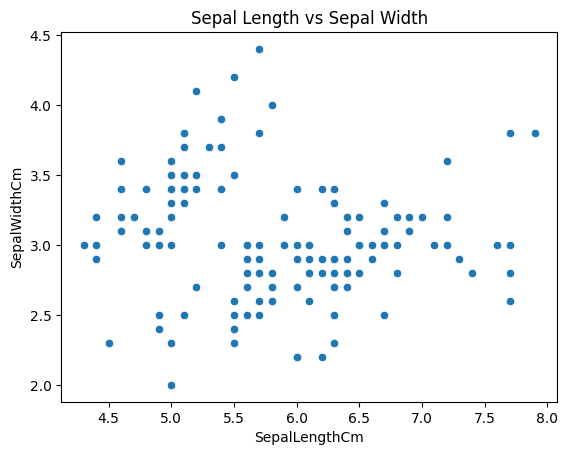

In [9]:
# Sepal Length vs Sepal Width
sns.scatterplot(data=df,x=df['SepalLengthCm'],y=df['SepalWidthCm'])
plt.title('Sepal Length vs Sepal Width')
plt.show()

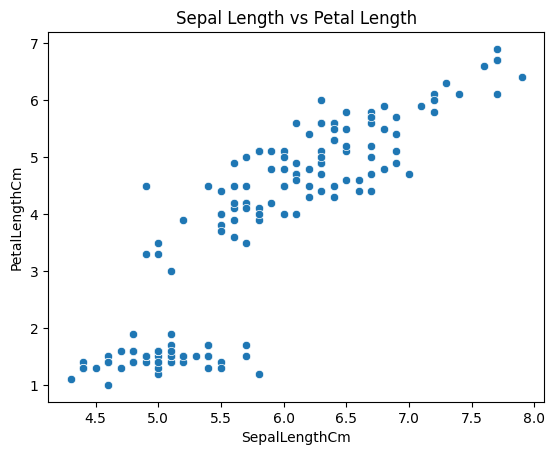

In [10]:
# Sepal Length vs Petal Length
sns.scatterplot(data=df,x=df['SepalLengthCm'],y=df['PetalLengthCm'])
plt.title('Sepal Length vs Petal Length')
plt.show()

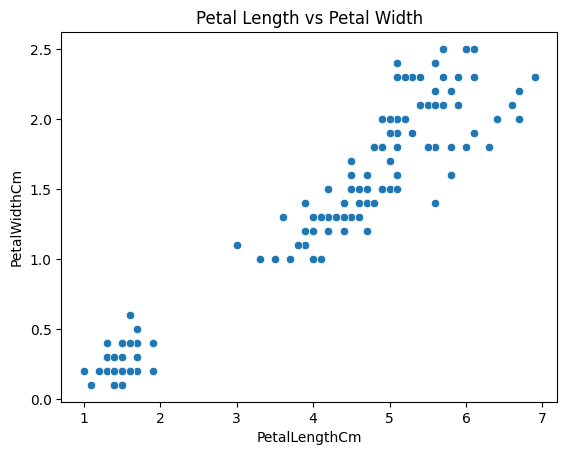

In [11]:
# Petal Length vs Petal Width
sns.scatterplot(data=df,x=df['PetalLengthCm'],y=df['PetalWidthCm'])
plt.title('Petal Length vs Petal Width')
plt.show()

# 2. HISTOGRAM PLOTS


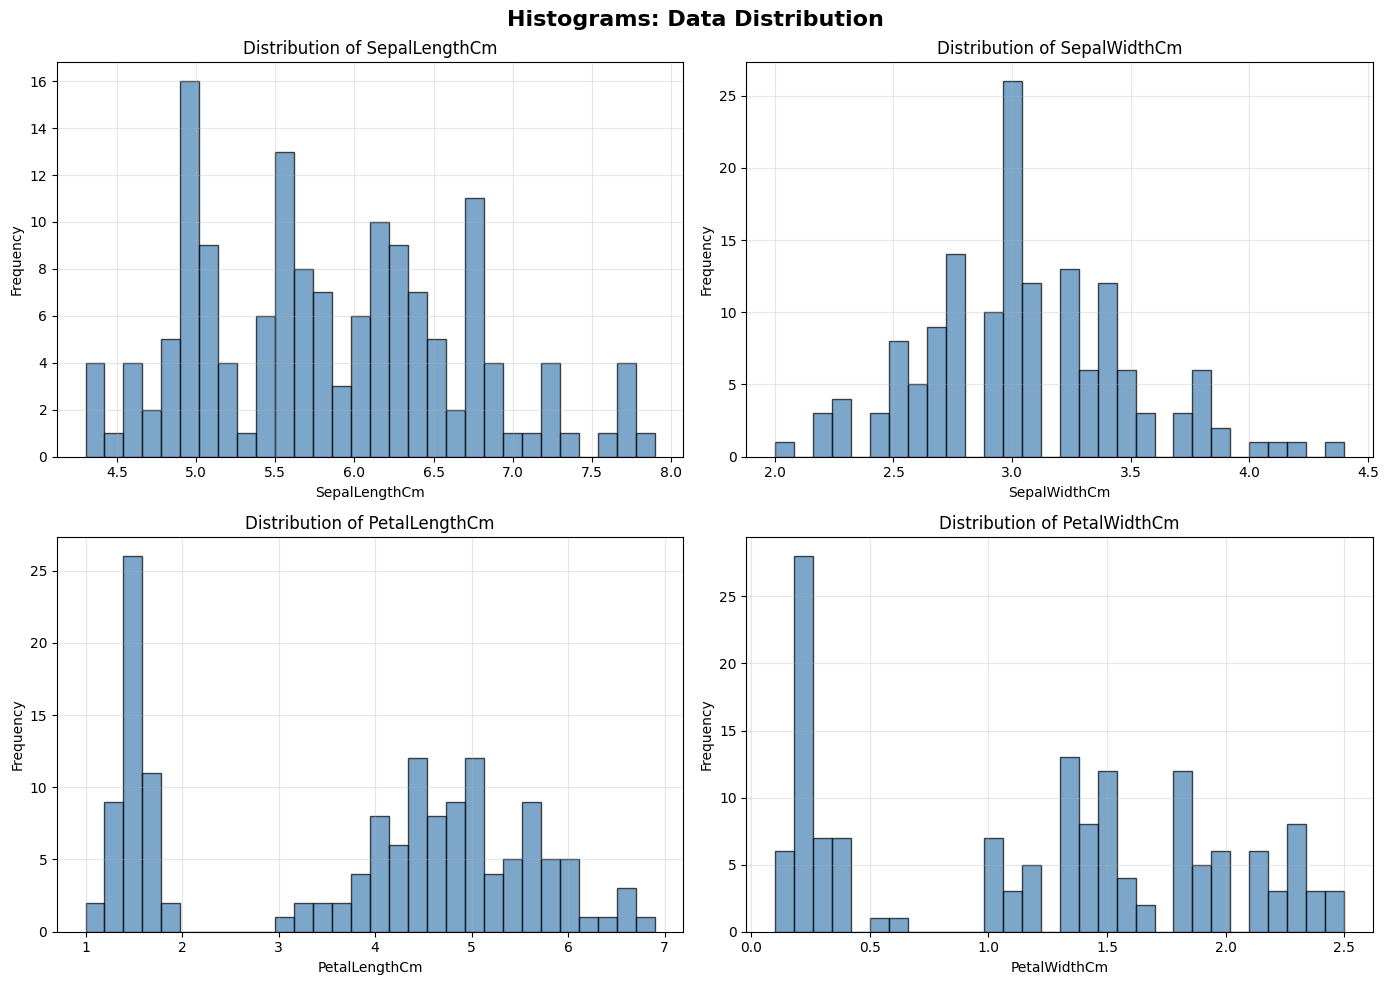

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Histograms: Data Distribution', fontsize=16, fontweight='bold')
 
for idx, col in enumerate(numeric_cols):
    row = idx // 2
    col_idx = idx % 2
    axes[row, col_idx].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('Frequency')
    axes[row, col_idx].set_title(f'Distribution of {col}')
    axes[row, col_idx].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()

# 3. BOXPLOTS

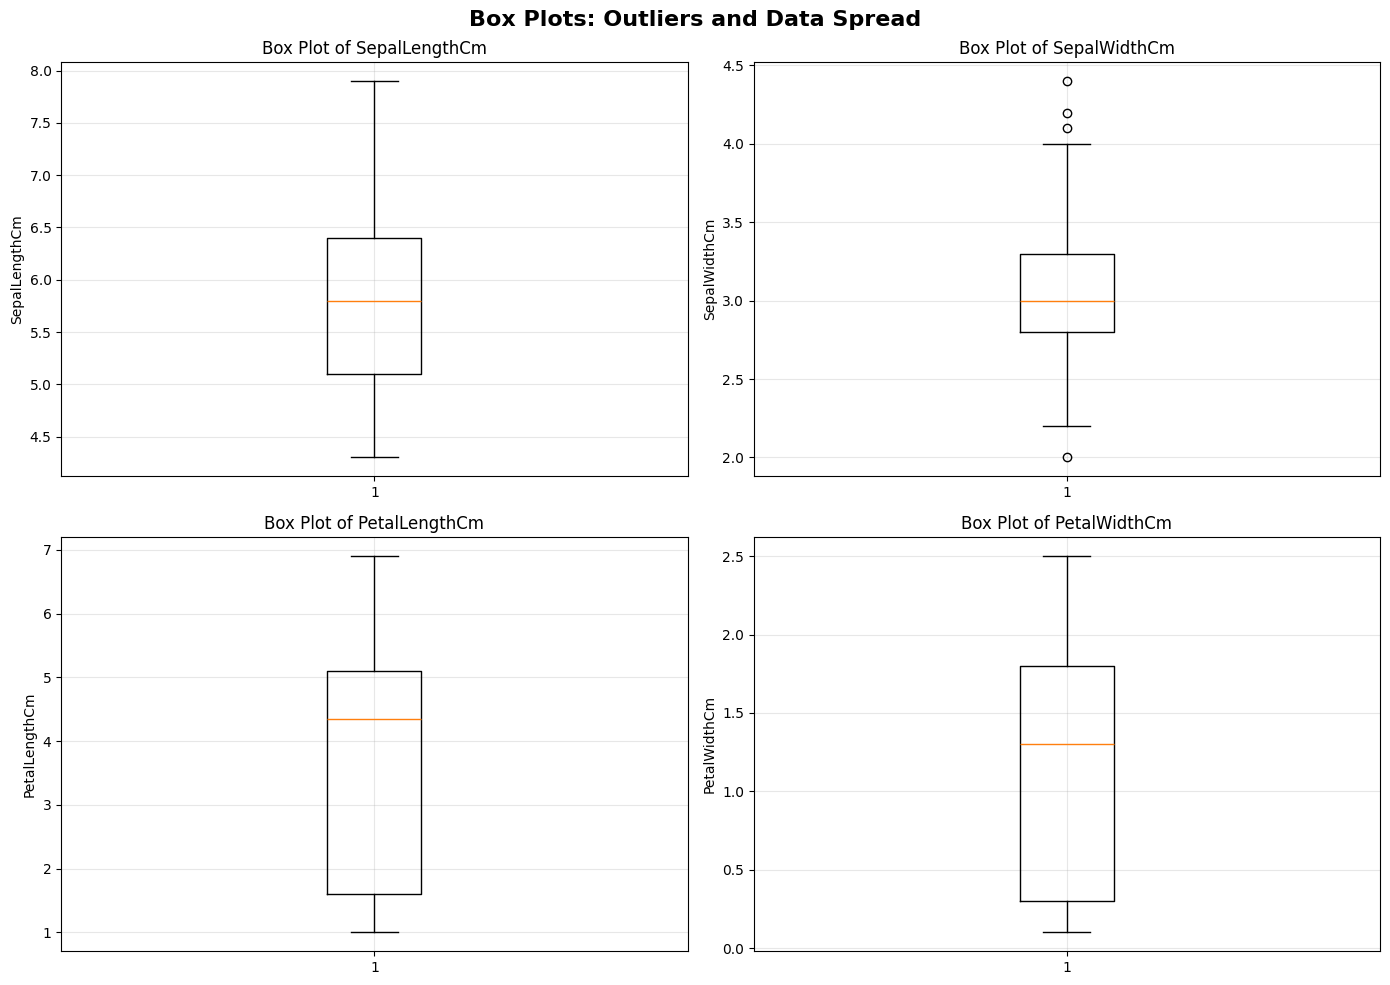

In [13]:
fig,axes= plt.subplots(2,2,figsize=(14,10))
fig.suptitle('Box Plots: Outliers and Data Spread', fontsize=16, fontweight='bold')

for idx,col in enumerate(numeric_cols):
    row= idx // 2
    col_idx= idx % 2
    axes[row, col_idx].boxplot(df[col],vert=True)
    axes[row, col_idx].set_ylabel(col)
    axes[row, col_idx].set_title(f'Box Plot of {col}')
    axes[row, col_idx].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()

# PREPARING THE DATA FOR MODEL TRAINING

In [14]:
# Separate features (X) and target (y)
X=df.drop(['Id','Species'],axis=1)
y=df['Species']                         # Target (species name)

In [15]:
print(f"\nFeatures (X) shape: {X.shape}")
print(f"Features columns: {X.columns.tolist()}")
print(f"\nTarget (y) shape: {y.shape}")
print(f"Species classes: {y.unique().tolist()}")
print(f"\nClass distribution:\n{y.value_counts()}")


Features (X) shape: (150, 4)
Features columns: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

Target (y) shape: (150,)
Species classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

Class distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [16]:
# SPLIT DATA INTO TRAIN AND TEST SETS
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:\n{y_train.value_counts()}")
print(f"\nTest set class distribution:\n{y_test.value_counts()}")


Training set size: 120 samples
Test set size: 30 samples

Training set class distribution:
Species
Iris-setosa        40
Iris-virginica     40
Iris-versicolor    40
Name: count, dtype: int64

Test set class distribution:
Species
Iris-setosa        10
Iris-virginica     10
Iris-versicolor    10
Name: count, dtype: int64


In [17]:
# SCALE THE FEATURES
# Normalize features so they're all on the same scale
scaler= StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)
print("\nFeatures scaled successfully!")


Features scaled successfully!


In [18]:
# BUILD AND TRAIN THE MODEL
# Using Support Vector Machine (SVM) classifier
model=SVC(kernel='rbf',random_state=42)
model.fit(X_train_scaled,y_train)
print("Model trained!")

Model trained!


In [19]:
# MAKE PREDICTIONS ON TEST DATA
y_pred=model.predict(X_test_scaled)
print("Predictions made!")
print(f"\nFirst 10 predictions: {y_pred[:10]}")
print(f"First 10 actual values: {y_test.values[:10]}")

Predictions made!

First 10 predictions: ['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor']
First 10 actual values: ['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor']


In [20]:
# EVALUATE THE MODEL
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred,average='weighted')
recall=recall_score(y_test,y_pred,average='weighted')
f1=f1_score(y_test,y_pred,average='weighted')
print("MODEL PERFORMANCE METRICS")
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

MODEL PERFORMANCE METRICS
Accuracy:  0.9667 (96.67%)
Precision: 0.9697
Recall:    0.9667
F1-Score:  0.9666


In [21]:
# CONFUSION MATRIX
cm=confusion_matrix(y_test,y_pred)
print("\nConfusion Matrix")
print(cm)
print("\nInterpretation:")
print("- Diagonal values = correct predictions")
print("- Off-diagonal values = incorrect predictions")


Confusion Matrix
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Interpretation:
- Diagonal values = correct predictions
- Off-diagonal values = incorrect predictions


# CLASSIFICATION REPORT

In [22]:
print("\nDetailed Classification Report")
print(classification_report(y_test,y_pred))


Detailed Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



In [23]:
print("\nDetailed Classification Report")
print(classification_report(y_test,y_pred))


Detailed Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



In [24]:
# CROSS-VALIDATION
print("5-FOLD CROSS-VALIDATION")
cv_scores=cross_val_score(model,X_train_scaled,y_train,cv=5)
print(f"Individual fold scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation: {cv_scores.std():.4f}")

5-FOLD CROSS-VALIDATION
Individual fold scores: [0.91666667 1.         0.95833333 0.95833333 1.        ]
Mean CV accuracy: 0.9667
Standard deviation: 0.0312


In [25]:
# MAKE A SINGLE PREDICTION
# Example: New iris with these measurements
new_flower=[[5.8, 3.2, 4.5, 1.2]]         # [SepalLength, SepalWidth, PetalLength, PetalWidth]
# Scale the new flower using the same scaler
new_flower_scaled= scaler.transform(new_flower)
print("PREDICTING A NEW IRIS FLOWER")
# Make prediction
prediction= model.predict(new_flower_scaled)
confidence= model.decision_function(new_flower_scaled)
print(f"Measurements: {new_flower[0]}")
print(f"Predicted species: {prediction[0]}")
print(f"Confidence scores: {confidence}")

PREDICTING A NEW IRIS FLOWER
Measurements: [5.8, 3.2, 4.5, 1.2]
Predicted species: Iris-versicolor
Confidence scores: [[-0.19578755  2.23839675  0.82633351]]


c:\Users\cz3\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
